In [ ]:
%matplotlib inline


import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
from astropy.timeseries import LombScargle

add kepler-10b which is the lightcurve we are going to explore!

In [ ]:
search = lk.search_lightcurve('Kepler-10', mission='Kepler',
                              author='Kepler', exptime=1800)
search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 00,2009,Kepler,1800,kplr011904151,0.0
1,Kepler Quarter 01,2009,Kepler,1800,kplr011904151,0.0
2,Kepler Quarter 02,2009,Kepler,1800,kplr011904151,0.0
3,Kepler Quarter 03,2009,Kepler,1800,kplr011904151,0.0
4,Kepler Quarter 04,2010,Kepler,1800,kplr011904151,0.0
5,Kepler Quarter 05,2010,Kepler,1800,kplr011904151,0.0
6,Kepler Quarter 06,2010,Kepler,1800,kplr011904151,0.0
7,Kepler Quarter 07,2010,Kepler,1800,kplr011904151,0.0
8,Kepler Quarter 09,2011,Kepler,1800,kplr011904151,0.0


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

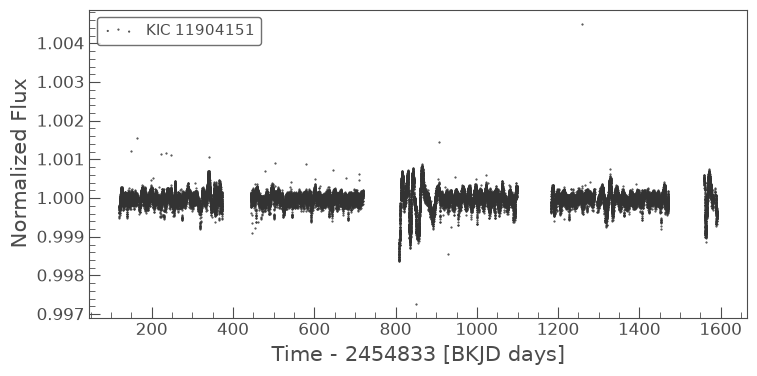

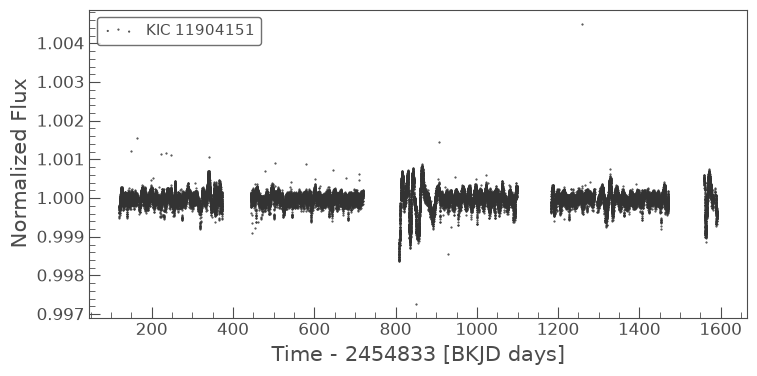

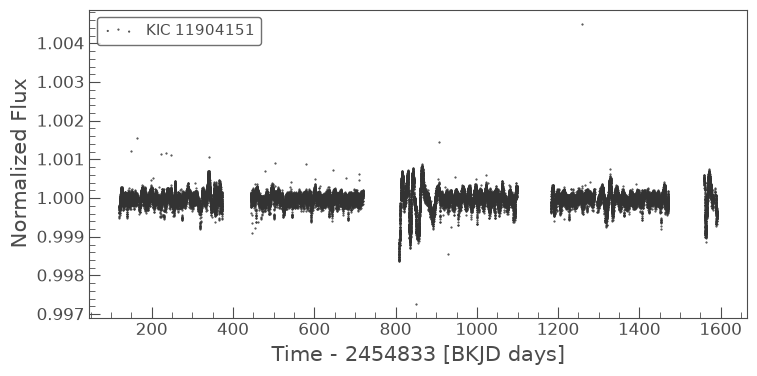

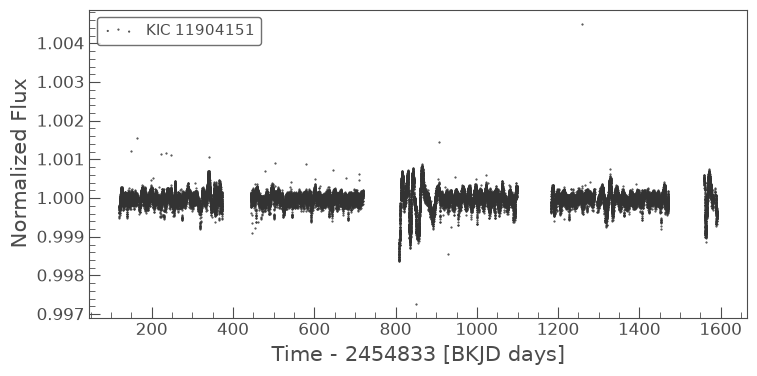

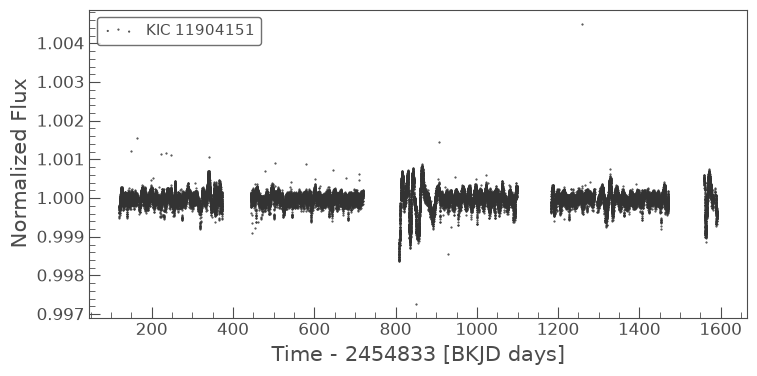

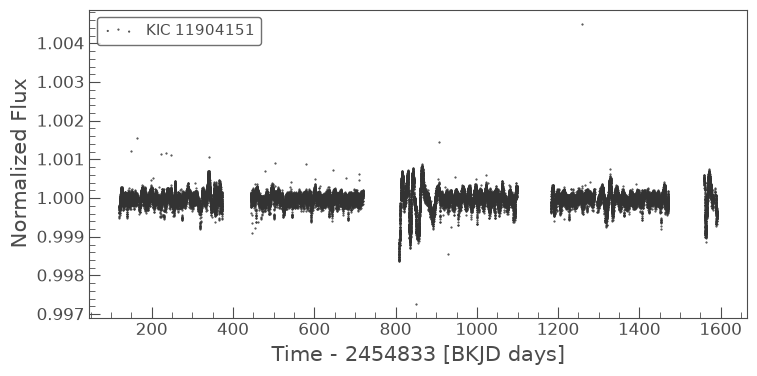

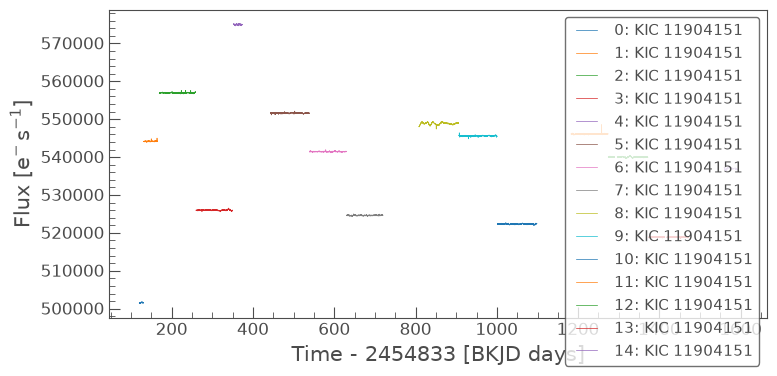

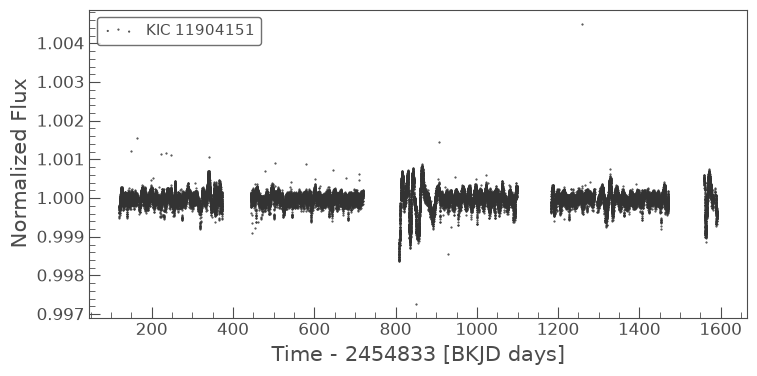

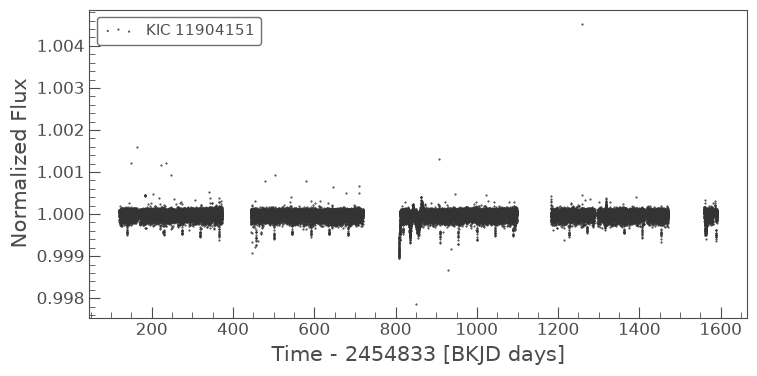

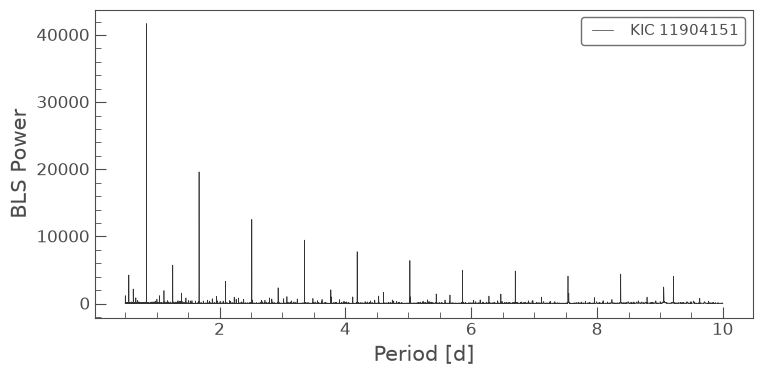

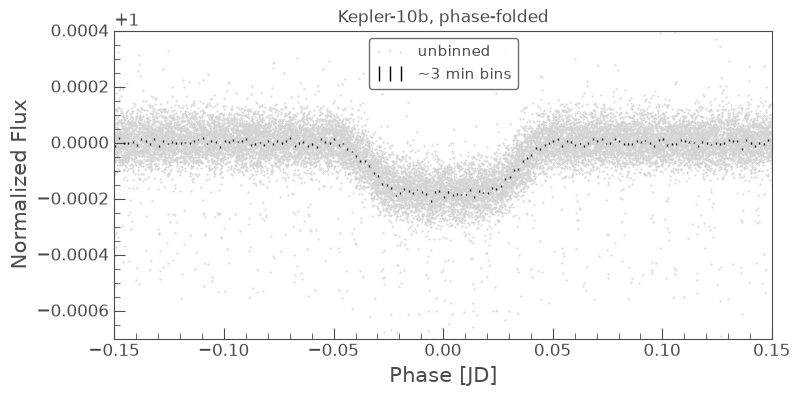

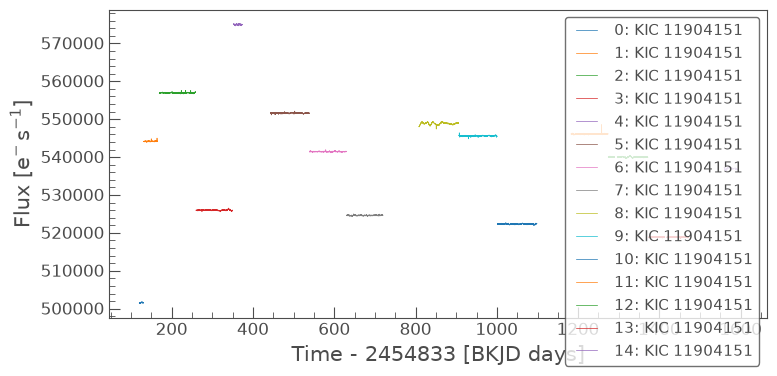

In [21]:
lc_collection = search.download_all()
lc_collection.plot()

51973 points;  flux unit: dimensionless (normalized)


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

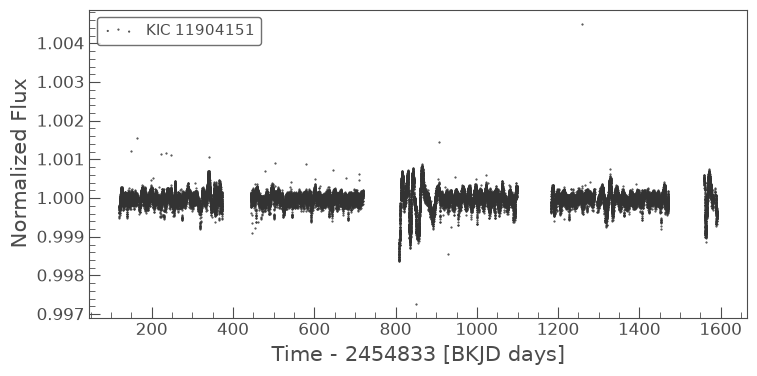

In [22]:
lc = lc_collection.stitch().remove_nans()
unit = str(lc.flux.unit) or 'dimensionless (normalized)'
print(f'{len(lc)} points;  flux unit: {unit}')
lc.scatter(s=1)

### Detrend

Remove long-timescale stellar variability and residual systematics with a
Savitzky-Golay filter, keeping the short transit signal.

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

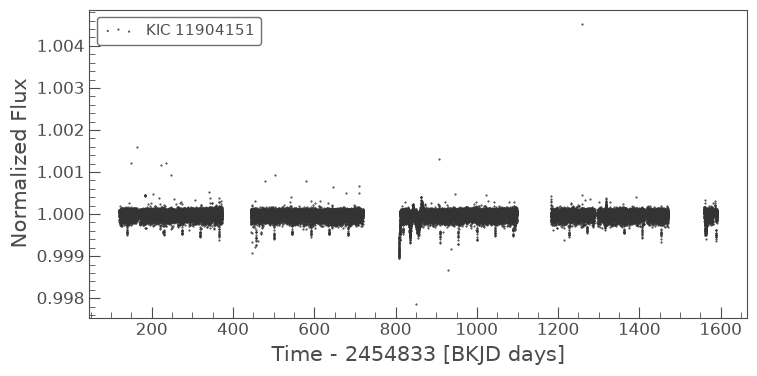

In [ ]:
flat = lc.flatten(window_length=101)
flat.scatter(s=1)

### Search for the period with BLS

`period` contains 273886 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


period   = 0.837494 d   (published: 0.837491)
epoch    = 120.6846 BKJD
duration = 99.4 min
depth    = 167.6 ppm


<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

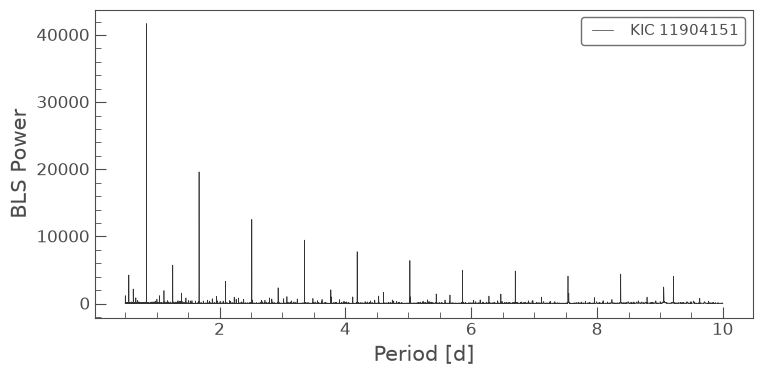

In [ ]:
pg = flat.to_periodogram(method='bls',
                         minimum_period=0.5, maximum_period=10,
                         duration=np.linspace(0.03, 0.10, 15),  
                         frequency_factor=500)                  

period = pg.period_at_max_power
t0     = pg.transit_time_at_max_power
dur    = pg.duration_at_max_power

print(f'period   = {period.value:.6f} ')
print(f'epoch    = {t0.value:.4f} BKJD')
print(f'duration = {dur.value * 24 * 60:.1f} min')
print(f'depth    = {pg.depth_at_max_power * 1e6:.1f} ppm')

pg.plot()

**`period` = 0.837494 d**
The orbital period: the time for the planet to complete one orbit,
measured as the spacing between consecutive transits.
(Published value: 0.837491 pretty close (side eyes here))

**`epoch` = 120.6846 BKJD**
A *reference* mid-transit time, in Barycentric Kepler Julian Date
(BKJD = BJD − 2,454,833). Transits occur at `epoch + n × period`.

**`duration` = 99.4 min**
How long the transit lasts — from the planet first overlapping the
star to fully clearing it. The star is always in the light
curve; it just gets slightly dimmer.

**`depth` = 167.6 ppm**
The fractional drop in flux during transit (167.6 ppm = 1.676 × 10⁻⁴)
.
$$\frac{R_p}{R_\star} \approx \sqrt{\text{depth}} \approx 0.0129$$


### Fold on the recovered ephemeris

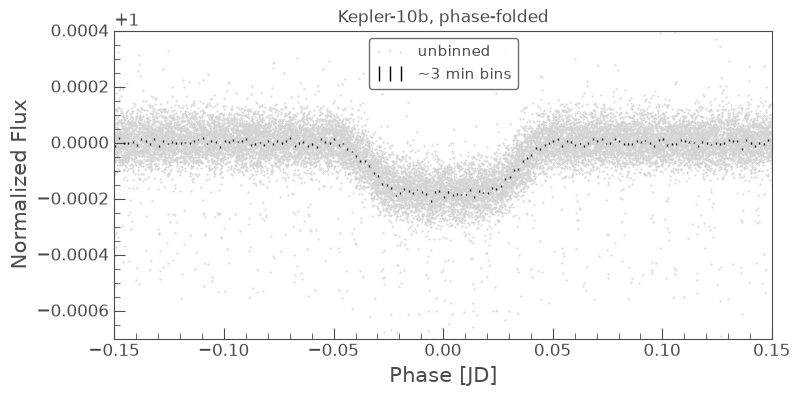

In [ ]:
folded = flat.fold(period=period, epoch_time=t0)

ax = folded.scatter(s=1, c='lightgray', label='unbinned')
folded.bin(time_bin_size=0.002).errorbar(ax=ax, c='k', lw=1, label='~3 min bins')
ax.set_xlim(-0.15, 0.15)
ax.set_ylim(0.9993, 1.0004)
ax.set_title('Kepler-10b');